# Experiment 5: conservative gradient-boosting tuning

This experiment tunes `GradientBoostingClassifier` without changing features or preprocessing. Candidate selection uses one fixed CV design; a separate 20-seed paired validation determines whether the winner generalizes. No leaderboard result participates.

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
SEARCH_CANDIDATES = 36
CONFIRMATION_SEEDS = list(range(19)) + [42]
N_BOOTSTRAP = 20_000
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
train = pd.read_csv(ROOT / 'data' / 'raw' / 'train.csv')
X_raw = train.drop(columns='Survived')
y = train['Survived']
print(f'Train: {train.shape}; search candidates: {SEARCH_CANDIDATES}; confirmation: 20 seeds × 5 folds')

Train: (891, 12); search candidates: 36; confirmation: 20 seeds × 5 folds


## Unchanged features and preprocessing

The model receives exactly the champion feature set: `Age`, `SibSp`, `Parch`, `Fare`, `Pclass`, `Sex`, `Embarked`, engineered `Title`, and engineered `IsAlone`. Numeric median imputation and categorical mode imputation plus dense one-hot encoding remain inside the pipeline. No scaling is added because gradient-boosted trees do not need it.

In [2]:
NUMERIC = ['Age', 'SibSp', 'Parch', 'Fare']
CATEGORICAL = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
COMMON_TITLES = {'Mr', 'Miss', 'Mrs', 'Master'}

def engineer_features(df):
    df = df.copy()
    title = df['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()
    df['Title'] = title.where(title.isin(COMMON_TITLES), 'Rare')
    df['IsAlone'] = ((df['SibSp'] + df['Parch']) == 0).astype(int)
    return df

X = engineer_features(X_raw)

def make_pipeline(model_params=None):
    preprocessing = ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median'), NUMERIC),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])
    estimator = GradientBoostingClassifier(random_state=RANDOM_STATE, **(model_params or {}))
    return Pipeline([('preprocessing', preprocessing), ('model', estimator)])

## Stage 1 — modest randomized search

A reproducible `RandomizedSearchCV` samples 36 candidates from bounded, interpretable choices around the default model. Candidate selection uses five shuffled stratified folds with seed 42. The default model is evaluated separately on exactly those folds. `max_features` is included because feature subsampling can regularize correlated one-hot predictors; choices are limited to all, 75%, or square root. Serial execution changes only runtime, not search results.

In [3]:
search_space = {
    'model__n_estimators': [60, 80, 100, 125, 150, 200],
    'model__learning_rate': [0.03, 0.05, 0.075, 0.10, 0.15],
    'model__max_depth': [1, 2, 3, 4],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__subsample': [0.70, 0.85, 1.00],
    'model__max_features': [None, 'sqrt', 0.75],
}
search_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    make_pipeline(), search_space, n_iter=SEARCH_CANDIDATES, scoring='accuracy',
    cv=search_cv, random_state=RANDOM_STATE, n_jobs=1, return_train_score=True, refit=True,
)
started = perf_counter()
search.fit(X, y)
search_seconds = perf_counter() - started
default_search_scores = cross_val_score(make_pipeline(), X, y, cv=search_cv, scoring='accuracy')
tuned_params = {key.removeprefix('model__'): value for key, value in search.best_params_.items()}
print(f'Search completed in {search_seconds:.1f}s')
print(f'Default identical-CV result: {default_search_scores.mean():.4f} ± {default_search_scores.std():.4f}')
print(f'Best search-CV result: {search.best_score_:.4f}')
print(f'Apparent search-CV gain: {search.best_score_ - default_search_scores.mean():+.4f}')
print('Best parameters:', tuned_params)

Search completed in 9.4s
Default identical-CV result: 0.8395 ± 0.0107
Best search-CV result: 0.8473
Apparent search-CV gain: +0.0078
Best parameters: {'subsample': 0.85, 'n_estimators': 60, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.05}


In [4]:
search_results = pd.DataFrame(search.cv_results_).sort_values(['rank_test_score', 'std_test_score'])
top_columns = [
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'mean_fit_time',
    *[f'param_{name}' for name in search_space],
]
top_candidates = search_results[top_columns].head(10).rename(columns={
    'rank_test_score': 'Rank', 'mean_test_score': 'CV mean', 'std_test_score': 'CV std',
    'mean_train_score': 'Train mean', 'mean_fit_time': 'Fit seconds/fold',
    **{f'param_{name}': name.removeprefix('model__') for name in search_space},
})
display(top_candidates.style.format({
    'CV mean': '{:.4f}', 'CV std': '{:.4f}', 'Train mean': '{:.4f}',
    'Fit seconds/fold': '{:.4f}',
}))

,Rank,CV mean,CV std,Train mean,Fit seconds/fold,n_estimators,learning_rate,max_depth,min_samples_split,min_samples_leaf,subsample,max_features
5,1,0.8473,0.0155,0.8858,0.0409,60,0.050000,4,2,8,0.850000,None
28,2,0.8451,0.0162,0.8757,0.0313,60,0.075000,3,20,4,0.700000,None
35,3,0.8451,0.0106,0.9237,0.0672,125,0.075000,4,2,4,0.700000,0.750000
4,4,0.8440,0.0057,0.8998,0.0797,200,0.100000,2,10,1,0.850000,None
33,5,0.8440,0.0213,0.9259,0.0726,125,0.075000,4,5,4,1.000000,0.750000
20,6,0.8440,0.0167,0.8914,0.0817,125,0.030000,4,2,4,1.000000,None
3,7,0.8406,0.0058,0.8779,0.0534,150,0.100000,2,2,4,0.700000,0.750000
23,8,0.8395,0.0118,0.8704,0.0611,125,0.030000,3,5,4,0.700000,None
34,9,0.8384,0.0084,0.8634,0.0453,125,0.075000,2,2,2,0.700000,0.750000
0,10,0.8384,0.0166,0.9172,0.0614,125,0.150000,3,5,8,0.700000,None


## Stage 2 — robust paired confirmation

The selected candidate is not accepted on its tuning folds. It is compared with the unchanged default over the Experiment 4 design: 20 seeds, five stratified folds per seed, and identical folds for both models. The primary uncertainty calculation bootstraps the 20 paired seed-mean differences, avoiding the false assumption that 100 overlapping folds are independent. The interval remains descriptive because observations recur across seeds.

In [5]:
fold_rows = []
for seed in CONFIRMATION_SEEDS:
    splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=seed).split(X, y))
    for fold, (train_idx, valid_idx) in enumerate(splits, 1):
        scores = {}
        for name, params in [('Default', None), ('Tuned', tuned_params)]:
            model = make_pipeline(params)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            scores[name] = model.score(X.iloc[valid_idx], y.iloc[valid_idx])
        fold_rows.append({
            'Seed': seed, 'Fold': fold, 'Default': scores['Default'], 'Tuned': scores['Tuned'],
            'PairedDifference': scores['Tuned'] - scores['Default'],
        })
fold_results = pd.DataFrame(fold_rows)
seed_results = fold_results.groupby('Seed', sort=False)[['Default', 'Tuned']].mean()
seed_results['PairedDifference'] = seed_results['Tuned'] - seed_results['Default']
assert len(fold_results) == 100 and len(seed_results) == 20
display(seed_results.style.format({'Default': '{:.4f}', 'Tuned': '{:.4f}',
                                   'PairedDifference': '{:+.4f}'}))

,Default,Tuned,PairedDifference
Seed,,,
0,0.8350,0.8282,-0.0067
1,0.8305,0.8272,-0.0034
2,0.8316,0.8294,-0.0023
3,0.8350,0.8204,-0.0146
4,0.8193,0.8272,+0.0079
5,0.8227,0.8294,+0.0067
6,0.8294,0.8339,+0.0045
7,0.8395,0.8350,-0.0045
8,0.8328,0.8272,-0.0056


In [6]:
differences = seed_results['PairedDifference'].to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_means = differences[rng.integers(0, len(differences),
                                           size=(N_BOOTSTRAP, len(differences)))].mean(axis=1)
ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])
wins = int((differences > 1e-12).sum())
ties = int(np.isclose(differences, 0, atol=1e-12).sum())
losses = int((differences < -1e-12).sum())
confirmation_summary = pd.DataFrame({
    'Statistic': [
        'Default overall fold accuracy', 'Tuned overall fold accuracy',
        'Mean paired seed difference', 'Median paired seed difference',
        '95% paired seed-bootstrap CI', 'Tuned seed wins', 'Seed ties', 'Seed losses',
        'Seed-42 paired difference',
    ],
    'Result': [
        f"{fold_results['Default'].mean():.4f} ± {fold_results['Default'].std(ddof=0):.4f}",
        f"{fold_results['Tuned'].mean():.4f} ± {fold_results['Tuned'].std(ddof=0):.4f}",
        f'{differences.mean():+.4f}', f'{np.median(differences):+.4f}',
        f'[{ci_low:+.4f}, {ci_high:+.4f}]',
        f'{wins}/20 ({wins/20:.0%})', f'{ties}/20 ({ties/20:.0%})',
        f'{losses}/20 ({losses/20:.0%})', f"{seed_results.loc[42, 'PairedDifference']:+.4f}",
    ],
})
display(confirmation_summary)

,Statistic,Result
0,Default overall fold accuracy,0.8325 ± 0.0250
1,Tuned overall fold accuracy,0.8304 ± 0.0257
2,Mean paired seed difference,-0.0021
3,Median paired seed difference,-0.0023
4,95% paired seed-bootstrap CI,"[-0.0048, +0.0006]"
5,Tuned seed wins,6/20 (30%)
6,Seed ties,0/20 (0%)
7,Seed losses,14/20 (70%)
8,Seed-42 paired difference,+0.0078


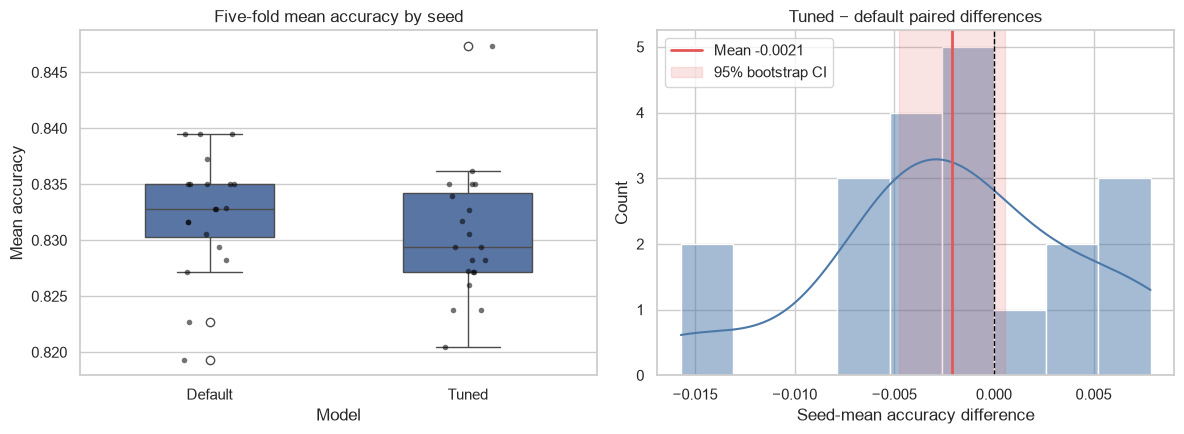

In [7]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
long_seed = seed_results.reset_index().melt(id_vars='Seed', value_vars=['Default', 'Tuned'],
                                             var_name='Model', value_name='Mean accuracy')
sns.boxplot(data=long_seed, x='Model', y='Mean accuracy', ax=axes[0], width=.5)
sns.stripplot(data=long_seed, x='Model', y='Mean accuracy', ax=axes[0], color='black', alpha=.55, size=4)
axes[0].set_title('Five-fold mean accuracy by seed')
sns.histplot(differences, bins=9, kde=True, ax=axes[1], color='#4C78A8')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(differences.mean(), color='#E45756', linewidth=2,
                label=f'Mean {differences.mean():+.4f}')
axes[1].axvspan(ci_low, ci_high, color='#E45756', alpha=.16, label='95% bootstrap CI')
axes[1].set(title='Tuned − default paired differences', xlabel='Seed-mean accuracy difference')
axes[1].legend()
plt.tight_layout()
plt.show()

## Decision

The search winner's apparent +0.0078 gain on the tuning folds reverses to −0.0021 in repeated confirmation. It loses on 14 of 20 seeds, and the paired bootstrap interval includes zero while lying mostly below it. Its fold-level standard deviation also rises slightly. The tuned configuration uses fewer trees (60 versus 100) and stronger leaf regularization, but increases tree depth from 3 to 4 and introduces 85% stochastic row subsampling. Thus it is not uniformly more complex computationally, yet the deeper/stochastic model is less stable and offers no generalizable accuracy gain.

The tuned candidate does **not** become champion. Retain the default `GradientBoostingClassifier`; do not spend a Kaggle submission on this candidate. Because confirmation fails, this notebook intentionally creates no submission file.